In [ ]:
# Banking Transaction Analytics Project

In [ ]:
# Banking Transaction Analytics Project

### Introduction

This project analyzes synthetic banking transaction data to provide actionable insights into branch performance, customer behavior, and transaction patterns. 
The goal is to demonstrate data analysis, visualization, and basic machine learning (customer segmentation) for banking operations. 

Skills demonstrated: Python, SQL-style analysis with pandas, data visualization, machine learning (KMeans), and financial analytics.

In [ ]:
### Dataset Overview

The dataset contains synthetic banking transaction data with the following columns:

- `TransactionID`: Unique ID for each transaction  
- `CustomerID`: Unique ID for each customer  
- `Branch`: Bank branch where the transaction occurred  
- `Date`: Date of the transaction  
- `TransactionType`: Type of transaction (Credit/Debit)  
- `Amount`: Transaction amount  
- `AccountBalance`: Customer's account balance after the transaction  

The dataset is used to analyze trends, branch performance, customer segmentation, and other key banking insights.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [8]:
# Load dataset
transactions = pd.read_csv('Banking_Transaction_Data.csv')
transactions.head()

,TransactionID,CustomerID,Date,Amount,TransactionType,AccountBalance,Branch
0,TXN00001,CUST0103,2025-01-22,1548.11,Debit,3276.37,Leeds
1,TXN00002,CUST0180,2025-03-07,1047.38,Credit,3300.76,Glasgow
2,TXN00003,CUST0093,2025-02-07,1952.27,Debit,3868.21,Birmingham
3,TXN00004,CUST0015,2025-03-31,259.84,Debit,5863.64,Glasgow
4,TXN00005,CUST0107,2025-02-15,43.73,Credit,2897.07,Glasgow


In [9]:
# Exploratory Analysis
print(transactions.describe())
print(transactions['TransactionType'].value_counts())

            Amount  AccountBalance
count  2000.000000     2000.000000
mean    997.662135     5195.360790
std     571.646913     2731.814716
min      10.020000      502.290000
25%     502.532500     2828.882500
50%    1005.635000     5153.270000
75%    1486.412500     7564.382500
max    1999.120000     9994.880000
TransactionType
Debit     1020
Credit     980
Name: count, dtype: int64


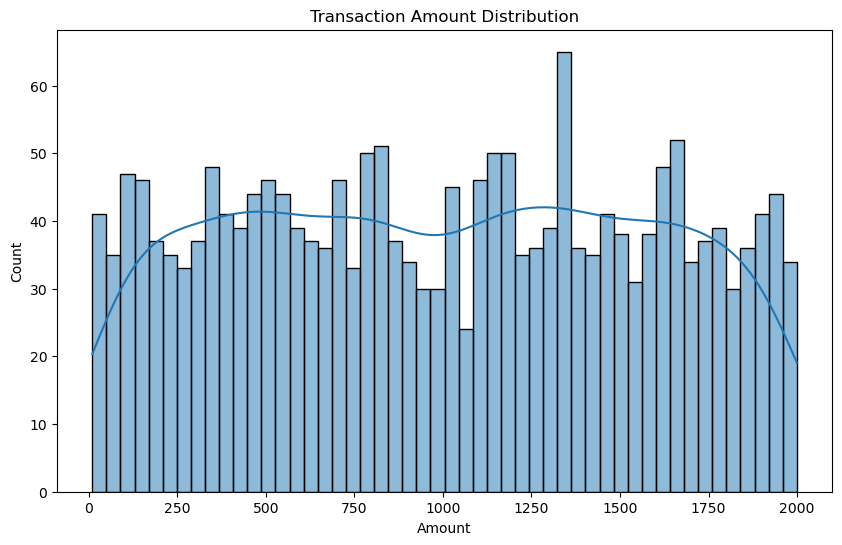

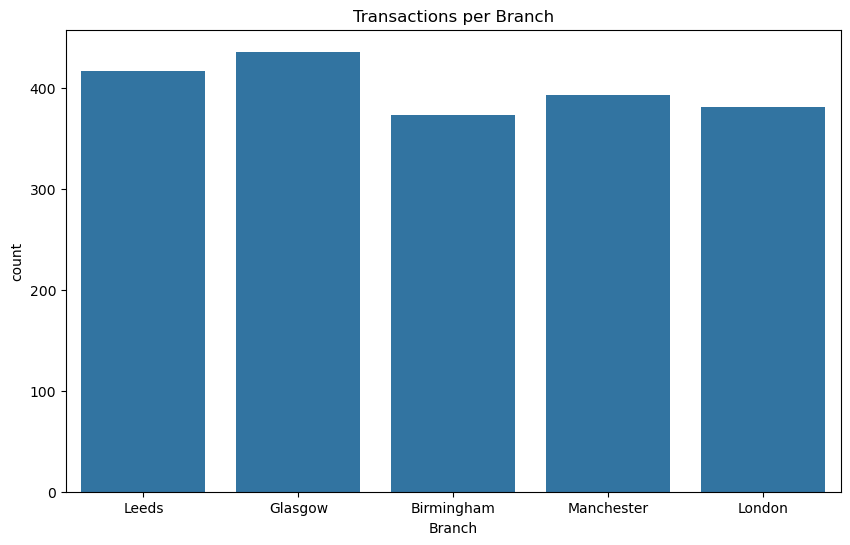

In [4]:
# Visualization
plt.figure(figsize=(10,6))
sns.histplot(transactions['Amount'], bins=50, kde=True)
plt.title('Transaction Amount Distribution')
plt.show()

plt.figure(figsize=(10,6))
sns.countplot(x='Branch', data=transactions)
plt.title('Transactions per Branch')
plt.show()

In [5]:
# SQL-like Analysis using pandas
branch_totals = transactions.groupby('Branch')['Amount'].sum().reset_index()
customer_totals = transactions.groupby('CustomerID')['Amount'].sum().reset_index().sort_values(by='Amount', ascending=False)
print(branch_totals)
print(customer_totals.head(10))

       Branch     Amount
0  Birmingham  391626.31
1     Glasgow  431402.57
2       Leeds  408418.96
3      London  366351.42
4  Manchester  397525.01
    CustomerID    Amount
178   CUST0179  21587.13
189   CUST0190  20149.69
160   CUST0161  19052.59
89    CUST0090  18971.97
38    CUST0039  17782.12
146   CUST0147  17660.68
152   CUST0153  17596.23
11    CUST0012  17351.64
186   CUST0187  17326.33
92    CUST0093  16708.18


In [ ]:
### Monthly Transaction Trend Analysis

In this section, we analyze the monthly transaction trends to understand how transaction volumes change over time. This helps identify seasonal patterns and periods of higher or lower customer activity.

By grouping transactions by month and summing the transaction amounts, we can visualize how the total transaction value evolves across different months.

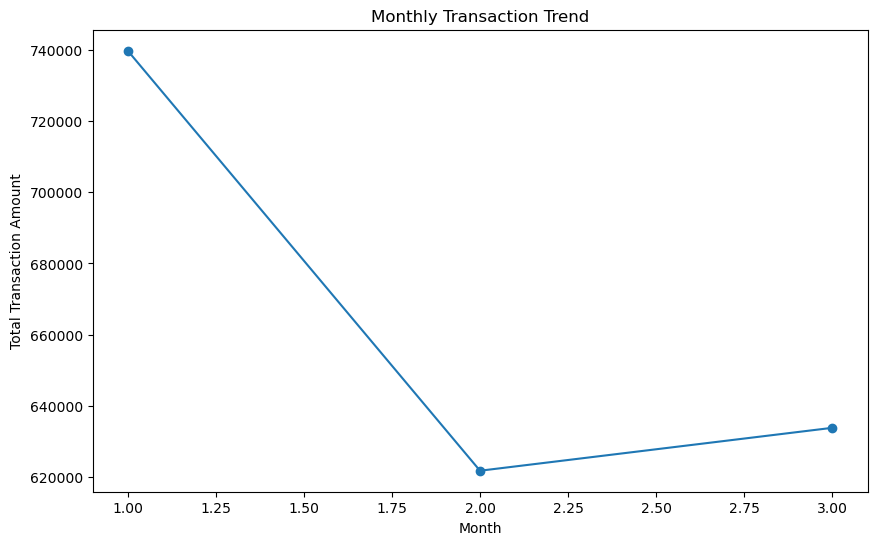

In [10]:
transactions['Date'] = pd.to_datetime(transactions['Date'])

monthly_transactions = transactions.groupby(transactions['Date'].dt.month)['Amount'].sum()

plt.figure(figsize=(10,6))
monthly_transactions.plot(kind='line', marker='o')
plt.title('Monthly Transaction Trend')
plt.xlabel('Month')
plt.ylabel('Total Transaction Amount')
plt.show()

In [ ]:
## Credit vs Debit Transaction Analysis

This analysis compares the total value of credit and debit transactions. 
Understanding the balance between incoming (credit) and outgoing (debit) transactions 
helps banks analyze customer spending behavior and cash flow patterns.

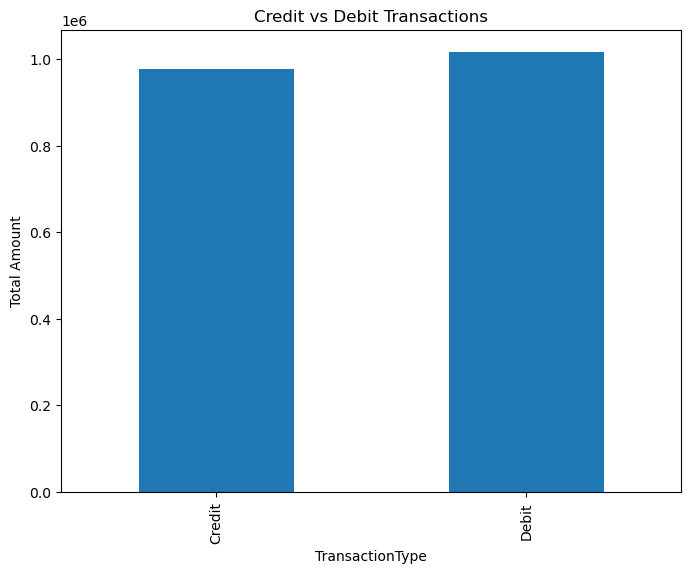

In [11]:
transaction_type_summary = transactions.groupby('TransactionType')['Amount'].sum()

plt.figure(figsize=(8,6))
transaction_type_summary.plot(kind='bar')
plt.title('Credit vs Debit Transactions')
plt.ylabel('Total Amount')
plt.show()

In [ ]:
## Branch Transaction Volume Analysis

This analysis examines the number of transactions processed by each bank branch. 
Understanding transaction volume helps identify which branches handle the most customer activity.

Branches with higher transaction counts may indicate stronger customer engagement, 
higher population density, or greater business activity in that region.

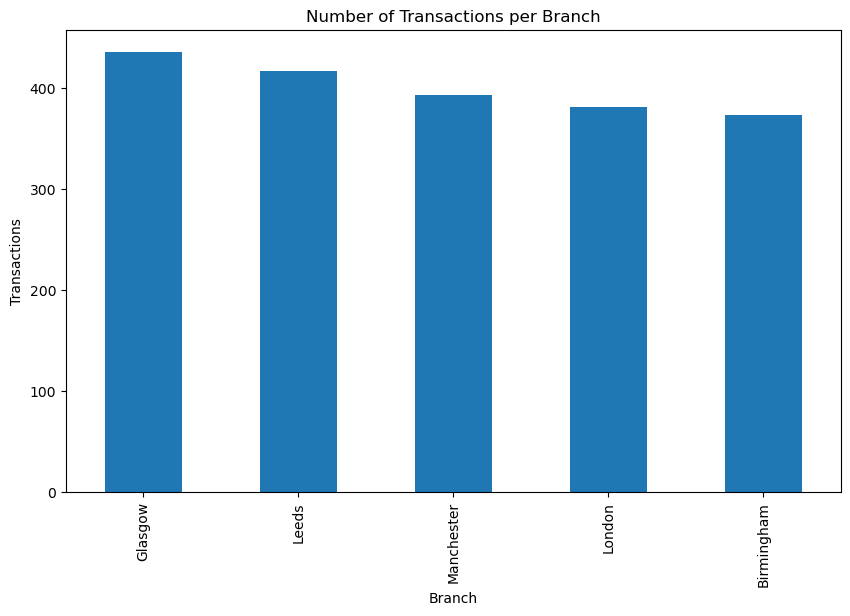

In [12]:
branch_transactions = transactions['Branch'].value_counts()

plt.figure(figsize=(10,6))
branch_transactions.plot(kind='bar')
plt.title('Number of Transactions per Branch')
plt.ylabel('Transactions')
plt.show()

In [13]:
avg_transaction = transactions['Amount'].mean()
print("Average Transaction Value:", avg_transaction)

Average Transaction Value: 997.662135


In [ ]:
### Key Insight

The average transaction value represents the typical amount customers transact in a single transaction. 
This metric helps banks understand general customer spending behavior.

A higher average transaction value may indicate higher purchasing power or larger financial activities 
among customers, while a lower value may suggest frequent smaller transactions.

In [ ]:
# Business Insights Summary

Based on the analysis of banking transaction data, several key insights were identified:

### 1. Branch Performance
The analysis shows that some branches generate higher total transaction amounts and process more transactions than others. This insight can help the bank identify high-performing branches and optimize resource allocation.

### 2. Customer Spending Behavior
By analyzing transaction amounts and identifying high-value customers, the bank can target these customers with premium services, personalized offers, or loyalty programs.

### 3. Credit vs Debit Patterns
The comparison between credit and debit transactions provides insight into customer financial behavior, helping the bank understand whether customers are primarily depositing or spending money.

### 4. Transaction Trends
Monthly transaction trends help the bank identify seasonal patterns in customer activity. This information can be useful for financial planning and marketing campaigns.

### 5. Customer Segmentation
Using clustering techniques, customers were grouped based on transaction behavior and account balances. This segmentation helps the bank design targeted financial products for different customer groups.

Overall, this analysis demonstrates how data-driven insights can help banks improve decision-making, customer engagement, and financial performance.

# Fraud Detection Analysis
This section identifies potentially fraudulent transactions using anomaly detection based on unusually large transaction amounts.

In [ ]:
# Fraud Detection using Transaction Amount Outliers
import numpy as np

threshold = transactions['Amount'].mean() + 3 * transactions['Amount'].std()
transactions['Fraud_Flag'] = transactions['Amount'] > threshold

fraud_transactions = transactions[transactions['Fraud_Flag'] == True]

print("Number of suspicious transactions detected:", fraud_transactions.shape[0])
fraud_transactions.head()


In [ ]:
Visualize Suspicious Transactions

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.histplot(transactions['Amount'], bins=50)
plt.axvline(threshold, linestyle='--')
plt.title('Transaction Amount Distribution with Fraud Threshold')
plt.show()


In [ ]:
Branch Fraud Analysis

In [ ]:
fraud_by_branch = fraud_transactions['Branch'].value_counts()

plt.figure(figsize=(8,5))
fraud_by_branch.plot(kind='bar')
plt.title('Suspicious Transactions by Branch')
plt.ylabel('Number of Fraud Flags')
plt.show()


## Fraud Detection Insights
• A small number of transactions were identified as unusually large compared to the normal transaction range.

• These transactions may require further investigation by the bank's fraud monitoring system.

• Branch-level analysis can help identify locations with unusually high-value transactions.
